In [1]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import seaborn as sns
import joblib

In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('data/titanic_clean.csv')

In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Nulls:", df.isnull().sum().sum())
df.head()

Shape: (891, 16)
Columns: ['Survived', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson']
Nulls: 0


,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,FamilySize,IsAlone,AgeGroup,FarePerPerson
0,0,1,22.0,1,0,2.110213,0,0,1,0,0,1,2,0,2,1.055107
1,1,0,38.0,1,0,4.280593,1,0,0,1,0,0,2,0,3,2.140297
2,1,0,26.0,0,0,2.188856,0,0,1,0,0,1,1,1,2,2.188856
3,1,0,35.0,1,0,3.990834,0,0,1,1,0,0,2,0,2,1.995417
4,0,1,35.0,0,0,2.202765,0,0,1,0,0,1,1,1,2,2.202765


In [5]:
x=df.drop('Survived', axis=1)
y=df['Survived']

In [6]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.2, random_state=20)

In [7]:
print(x_train.shape)
print(x_test.shape)

(712, 15)
(179, 15)


In [8]:
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)

In [9]:
models={ 
    'LogisticRegression' : LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM' : SVC(kernel='rbf', random_state=42)
    }

In [10]:
result={}
predictions={}

In [11]:
for name, model in models.items():
    model.fit(x_train_scale, y_train)
    pred=model.predict(x_test_scale)
    predictions[name]=pred
    acc=accuracy_score(y_test, pred)
    f1=f1_score(y_test, pred)
    cv=cross_val_score(model, x_train_scale, y_train, cv=5, scoring='accuracy').mean()
    result[name]={'Accuracy': acc, 'f1-score': f1, 'cross validation score': cv}
    print({name})
    print(result[name])
    print(confusion_matrix(y_test, pred))
    

{'LogisticRegression'}
{'Accuracy': 0.8435754189944135, 'f1-score': 0.7846153846153846, 'cross validation score': np.float64(0.7922190485570767)}
[[100  12]
 [ 16  51]]
{'RandomForest'}
{'Accuracy': 0.8156424581005587, 'f1-score': 0.7401574803149606, 'cross validation score': np.float64(0.7823007977937555)}
[[99 13]
 [20 47]]
{'SVM'}
{'Accuracy': 0.8379888268156425, 'f1-score': 0.7433628318584071, 'cross validation score': np.float64(0.8258839751797499)}
[[108   4]
 [ 25  42]]


In [15]:
print(f"\n{'='*40}")
print(f"  {name}")
print(f"{'='*40}")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  CV Score : {cv:.4f}")
print(f"  Confusion Matrix:")
print(confusion_matrix(y_test, pred))

# Step 4 — Summary table
print("\n\n=== FINAL COMPARISON ===")
summary = pd.DataFrame(result).T
print(summary.round(4))
print(f"\n🏆 Best model: {summary['cross validation score'].idxmax()}")


  SVM
  Accuracy : 0.8380
  F1 Score : 0.7434
  CV Score : 0.8259
  Confusion Matrix:
[[108   4]
 [ 25  42]]


=== FINAL COMPARISON ===
                    Accuracy  f1-score  cross validation score
LogisticRegression    0.8436    0.7846                  0.7922
RandomForest          0.8156    0.7402                  0.7823
SVM                   0.8380    0.7434                  0.8259

🏆 Best model: SVM


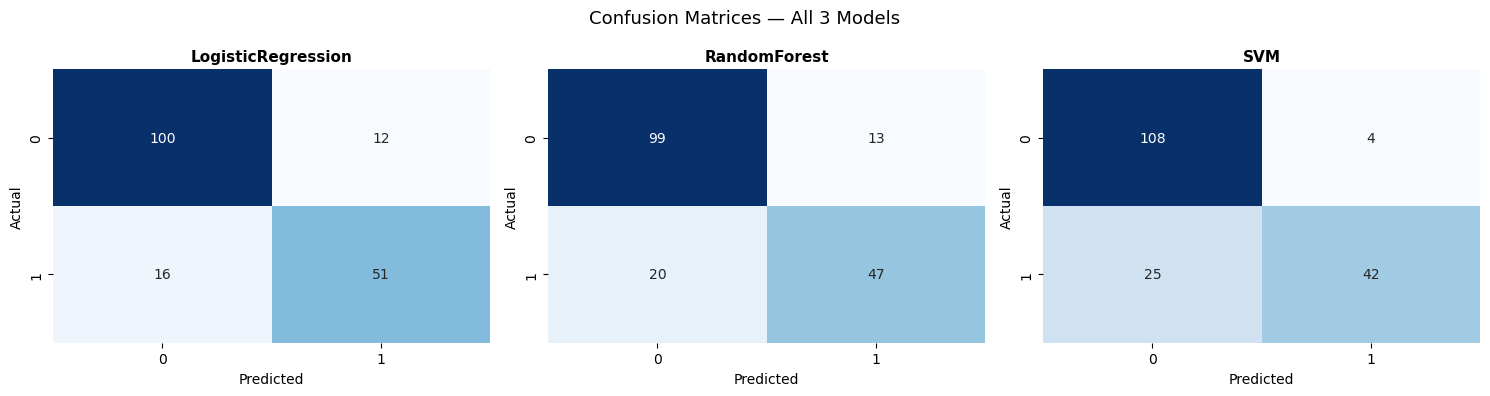

plot4 saved ✓


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

#os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_names = list(models.keys())
model_preds = list(predictions.values())

for ax, name, pred in zip(axes, model_names, model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=ax, cbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=13)
plt.tight_layout()
plt.savefig('plots/plot4_confusion_matrices.png', dpi=150)
plt.show()
print("plot4 saved ✓")

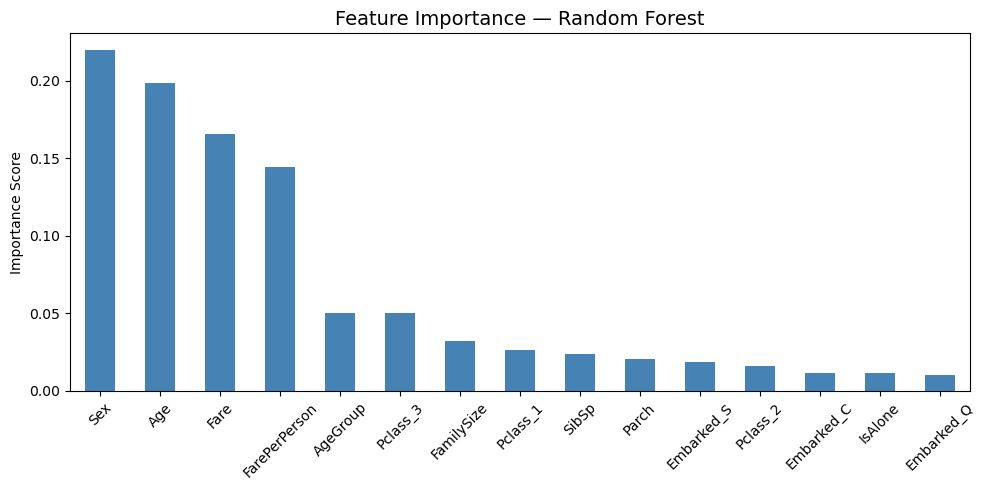


Top 5 most important features:
Sex              0.219689
Age              0.198345
Fare             0.165964
FarePerPerson    0.144159
AgeGroup         0.050282
dtype: float64


In [94]:
# Feature importance from Random Forest
rf_model = models['RandomForest']
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/plot5_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.head(5))

In [99]:
os.makedirs('models', exist_ok=True)

for name, model in models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'models/{filename}.pkl')
    print(f"Saved: models/{filename}.pkl")

joblib.dump(scaler, 'models/scaler.pkl')
print("Saved: models/scaler.pkl")
print("\nAll models saved ✓")

Saved: models/logisticregression.pkl
Saved: models/randomforest.pkl
Saved: models/svm.pkl
Saved: models/scaler.pkl

All models saved ✓
